# Spatial visualization

In [ ]:
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings("ignore")

## Input

In [3]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)

sc.settings.figdir = fig_path
input_path = os.path.join(expr_path, 'DE analysis')

In [4]:
adata = sc.read_h5ad(os.path.join(expr_path, '2025-07-03-finalized-ct-rgn.h5ad'))
adata

AnnData object with n_obs × n_vars = 538188 × 3447
    obs: 'sample', 'fov_id', 'volume', 'fov_x', 'fov_y', 'seg_label', 'global_x', 'global_y', 'sample_id', 'condition', 'protocol', 'unique_index', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes', 'n_counts', 'replicate', 'coronal_position', 'genotype', 'protocol_replicate', 'genotype_protocol_replicate', 'leiden', 'orig_leiden', 'level_1', 'level_2', 'level_3', 'global_x_aligned', 'global_y_aligned', 'region_label', 'ARG_score', 'OXFOS_score', 'Ribosome_score', 'ARG_score_region_delta', 'OXFOS_score_region_delta', 'Ribosome_score_region_delta', 'level_3_label', 'coronal_position_label'
    var: 'highly_variable', 'mean', 'std', 'max_counts'
    uns: 'level_1_color_dict', 'level_1_colors', 'level_1_order', 'level_2_color_dict', 'level_2_colors', 'level_2_order', 'leve

## Color palettes

In [6]:
# export as editable fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

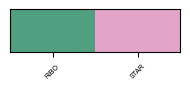

In [7]:
# RIBO, STAR, Common
protocol_order = ['RIBO', 'STAR']
protocol_pl = sns.color_palette(['#509f80', '#e3a4ca'])
protocol_cmap = ListedColormap(protocol_pl.as_hex())
sns.palplot(protocol_pl)
plt.xticks(range(len(protocol_order)), protocol_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'test.pdf'))
plt.show()

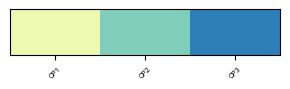

In [8]:
# CP1, CP2, CP3
cp_order = ['CP1', 'CP2', 'CP3']
cp_pl = sns.color_palette(['#edf8b1', '#7fcdbb', '#2c7fb8'])
cp_cmap = ListedColormap(cp_pl.as_hex())
sns.palplot(cp_pl)
plt.xticks(range(len(cp_order)), cp_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

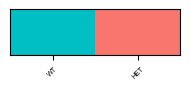

In [9]:
# WT, HET
condition_order = ['WT', 'HET']
condition_pl = sns.color_palette(['#00bfc4', '#f8766d'])
condition_cmap = ListedColormap(condition_pl.as_hex())
sns.palplot(condition_pl)
plt.xticks(range(len(condition_order)), condition_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

## Spatial visualization

In [10]:
region_ct_dict = {
    'CTX_L2/3': ["TEGLU", "TEINH"],
    'CTX_L4': ["TEGLU", "TEINH"],
    'CTX_L5': ["TEGLU", "TEINH"],
    'CTX_L6': ["TEGLU", "TEINH"],
    'CTX_ILA2/3': ["TEGLU", "TEINH"],
    'CTX_mPFC5': ["TEGLU", "TEINH"],
    'CTXsp': ["TEGLU", "TEINH"],
    'CTX_AI2/3': ["TEGLU", "TEINH"],
    'CTX_CA1': ["TEGLU", "TEINH"],
    'CTX_CA3': ["TEGLU", "TEINH"],
    "CTX_DG": ["TEGLU", "DGGRC", "TEINH"],
    "STR": ["MSN"],
    "PAL": ["PEP"],
    "TH_1": ["DEGLU"],
    "TH_2": ["DEGLU"],
    "TH_EPI": ["HABCHO"],
    "TH_RT": ["TEINH"],
    "HY": ["PEP", "TEINH"],
}


mask = (
    (adata.obs['level_1'] == 'Neuron') &
    adata.obs.apply(
        lambda r: r['level_2'] in region_ct_dict.get(r['region_label'], []),
        axis=1
    )
)
# Add / overwrite the flag column
adata.obs['spatial_analysis'] = mask

In [11]:
adata.X = adata.layers['raw'].copy()
sc.pp.normalize_total(adata, target_sum=1e3)
sc.pp.log1p(adata, base=2)
adata.layers['log2_norm1e3'] = adata.X.copy()

### Gene list

In [12]:
# Load all sheets from the Excel file into a dictionary
l2_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_2_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l2_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l2_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

In [13]:
# Load all sheets from the Excel file into a dictionary
l3_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_3_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l3_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l3_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

In [14]:
# load custom gene list
go_annot_df = pd.read_excel(os.path.join(base_path, 'documents', 'c5.all.v7.2.symbols.xlsx'), header=None)
go_annot_df = go_annot_df.drop([1], axis=1)
go_annot_df = go_annot_df.T
go_annot_df.columns = go_annot_df.iloc[0]
go_annot_df = go_annot_df.drop([0])

GO_dict = {}
for curruent_term in go_annot_df.columns:
    GO_dict[curruent_term] = [gene for gene in go_annot_df[curruent_term].dropna()]

In [15]:
ox_phos_genes = [g for g in adata.var_names if g.upper() in GO_dict['GO_OXIDATIVE_PHOSPHORYLATION']]
ribosome_genes = [g for g in adata.var_names if g.upper() in GO_dict['GO_RIBOSOME']] 
response_to_dopamine_genes = [g for g in adata.var_names if g.upper() in GO_dict['GO_RESPONSE_TO_DOPAMINE']]
sig_dopamine = [g for g in adata.var_names if g.upper() in GO_dict['GO_DOPAMINE_RECEPTOR_SIGNALING_PATHWAY']]
sig_serotonin = [g for g in adata.var_names if g.upper() in GO_dict['GO_SEROTONIN_RECEPTOR_SIGNALING_PATHWAY']]

In [16]:
adata.X = adata.layers['log2_norm1e4_scaled'].copy()
sc.tl.score_genes(adata, gene_list=ox_phos_genes, score_name='OXFOS_score')
sc.tl.score_genes(adata, gene_list=ribosome_genes, score_name='Ribosome_score')
sc.tl.score_genes(adata, gene_list=response_to_dopamine_genes, score_name='Response_to_dopamine_score')
sc.tl.score_genes(adata, gene_list=sig_dopamine, score_name='Sig_dopamine_score')
sc.tl.score_genes(adata, gene_list=sig_serotonin, score_name='Sig_serotonin_score')

In [17]:
ARG_list = [
    'Egr4', 'Fosb', 'Npas4', 'Fos', 'Btg2', 'Ier2', 'Amigo3', 'Egr3', 'Dusp1', 'Klf4', 
    'Arc', 'Gadd45g', 'Ppp1r15a', 'Egr2', 'Dusp5', 'Maff', 'Junb', 'Nr4a1', 'Egr1', 'Fndc9', 
    'Scg2', 'Glt28d2', 'Mbnl2', 'Maml3', 'Csrnp1', 'Sv2c', 'Hsd17b12', 'Crhbp', 'Col10a1', 'Gch1', 
    'Tac1', 'Errfi1', 'C2cd4b', 'Prok2', 'Slc2a3', 'Cartpt', 'Kcnj3', 'Chrm2', 'Mlf1', 'Dusp4', 
    'Popdc3', 'Ccdc184', 'Dusp14', 'Kcnf1', 'Alpk1', 'Rgs2', 'Wdr90', 'Grasp', 'Coq10b', 'Fam126b', 
    'Mctp2', 'Bdnf', 'Gem', 'Tiparp', 'Gpr22', 'Pcsk1', 'Cystm1', 'Ptgs2', 'Dmxl1', 'Per1', 
    'Cdkn1a', 'Ptger4', 'Fbxo33', 'Adm', 'Sik1', 'Pax1', 'Crem', 'Pou3f1', 'Spty2d1', 'Chst8', 
    'Tbc1d8b', 'Pgap1', 'Zdbf2', 'Lipg', 'Bves', 'Adcyap1', 'Chml', 'Slc7a1', 'Klf14', 'Pcdh8', 
    'Rgs4', 'Areg', 'Rnf128', 'Nap1l5', 'Peg10', 'Tnn', 'Nr4a3', 'Stk40', 'Atp10d', 'Rel', 
    'Slc6a17', 'Slc40a1', 'Mthfd2', 'Brinp1', 'Nrn1', 'Per2', 'Msantd1', 'Rem2', 'Gprc5a', 'Eprs', 
    'Pam', 'Sertad1', 'Tacr3', 'Hcrtr2', 'Herpud1', 'Stard4', 'Nppc', 'Pard6a', 'Plagl1', 'Pcdh20', 
    'Osgin2', 'Mpp7', 'Kcns2', 'Cort', 'Sstr2', 'Ell2', 'Gpr26', 'Sult2b1', 'Rheb', 'Acsl4', 
    'Nr4a2', 'Nefl', 'Fosl2', 'Tec', 'Fam46a', 'Gmeb2', 'Rasgrp1', 'Gltscr2', 'Atf3', 'Kitl', 
    'Baz1a', 'Npbwr1', '4931440P22Rik', 'Cfap43', 'D16Ertd472e', 'Meox1', 'Kcnj4', 'Gpr3', 'Trip10', 
    'Cd109', 'Gpr63', 'Tll1', 'Bmp3', 'Stc1', 'Klhl4', 'Sostdc1', 'Spred3', 'Sowahb', 'Slitrk4', 
    'Mfap3l', 'Kcna1', 'Fezf2', 'Dennd2c', 'Stc2', 'Hdac9', 'Hunk', 'Pthlh', 'Pnoc', 'Kcnh8', 
    'Acan', 'Gper1', 'Omg', 'Chac1', 'Stac', 'Nptx2', 'Kcna4', 'Sema3e', 'Palmd', 'Rab39', 
    'Serpinb2', 'Hspb3', '5430416O09Rik', '9430020K01Rik'
]

In [18]:
# IEG score
IEG_list = [
    "Arc", "Atf3", "Bdnf", "Btg2", "Dusp1","Ier2",
    "Klf4","Dusp5","Dusp6",
    "Ptgs2", "Homer1", "Fosl2",
    "Egr1", "Egr2", "Egr3", "Egr4",
    "Fos", "Fosb", "Gadd45g", "Junb", "Jun",
    "Npas4",
    "Nr4a1", "Nr4a2", "Nr4a3",
    "Nrn1", "Rgs2",
]

In [19]:
adata.X = adata.layers['log2_norm1e4_scaled'].copy()
sc.tl.score_genes(adata, gene_list=IEG_list, score_name='IEG_score')
sc.tl.score_genes(adata, gene_list=ARG_list, score_name='ARG_score')

       'Maml3', 'Csrnp1', 'Col10a1', 'C2cd4b', 'Ccdc184', 'Alpk1', 'Rgs2',
       'Wdr90', 'Mctp2', 'Fbxo33', 'Pax1', 'Crem', 'Chst8', 'Tbc1d8b', 'Pgap1',
       'Zdbf2', 'Bves', 'Klf14', 'Tnn', 'Atp10d', 'Per2', 'Msantd1', 'Gprc5a',
       'Eprs', 'Herpud1', 'Osgin2', 'Mpp7', 'Sult2b1', 'Nefl', 'Tec', 'Fam46a',
       'Gmeb2', 'Gltscr2', 'Baz1a', '4931440P22Rik', 'Cfap43', 'D16Ertd472e',
       'Gpr63', 'Tll1', 'Klhl4', 'Dennd2c', 'Stc2', 'Acan', 'Gper1', 'Omg',
       'Chac1', 'Stac', 'Kcna4', 'Rab39', 'Serpinb2', 'Hspb3', '5430416O09Rik',
       '9430020K01Rik'],
      dtype='object')


In [7]:
# load gsmap results
gsmap_path = os.path.join(output_path, 'gsmap/scz_output')
wt_samples = adata.obs.loc[adata.obs['condition'] == 'WT', 'sample_id'].unique()

res_dfs = []
for sample in tqdm(wt_samples):
    current_df = pd.read_csv(os.path.join(gsmap_path, sample, "spatial_ldsc", f'{sample}_scz.csv.gz'))
    res_dfs.append(current_df)

res_df = pd.concat(res_dfs)
res_df.index = res_df['spot']
res_df = res_df.drop(columns=['spot'])
res_df['gsmap_score'] = -np.log10(res_df['p'])
adata.obs = pd.merge(adata.obs, res_df, left_index=True, right_index=True, how='left')
adata.obs

  0%|          | 0/12 [00:00<?, ?it/s]

,sample,fov_id,volume,fov_x,fov_y,seg_label,global_x,global_y,sample_id,condition,...,ARG_score_region_delta,OXFOS_score_region_delta,Ribosome_score_region_delta,level_3_label,coronal_position_label,beta,se,z,p,gsmap_score
unique_index,,,,,,,,,,,,,,,,,,,,,
sample8_Position688_1,sample8,Position688,9514,1823,1116,1,1823,2969,sample8,HET,...,-0.007890,0.012028,0.017348,VEN,CP2,NaN,NaN,NaN,NaN,NaN
sample8_Position688_2,sample8,Position688,9109,132,173,2,132,2026,sample8,HET,...,-0.007890,0.012028,0.017348,VLM_2,CP2,NaN,NaN,NaN,NaN,NaN
sample8_Position688_3,sample8,Position688,5644,1298,712,3,1298,2565,sample8,HET,...,-0.007890,0.012028,0.017348,PER,CP2,NaN,NaN,NaN,NaN,NaN
sample8_Position688_5,sample8,Position688,6673,1287,1491,5,1287,3344,sample8,HET,...,-0.007890,0.012028,0.017348,AC_2,CP2,NaN,NaN,NaN,NaN,NaN
sample8_Position688_6,sample8,Position688,12560,731,1370,6,731,3223,sample8,HET,...,-0.007890,0.012028,0.017348,Mix,CP2,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sample22_Position343_143,sample22,Position343,10444,868,888,143,26717,10169,sample22,WT,...,-0.007890,0.012028,0.017348,TEGLU_Mix,CP1,3.310460e-08,7.958920e-09,4.159433,0.000016,4.797188
sample22_Position343_144,sample22,Position343,4450,1049,1803,144,26898,11084,sample22,WT,...,0.015026,-0.039242,-0.064635,VEN,CP1,1.906568e-08,9.564769e-09,1.993324,0.023113,1.636144
sample22_Position343_145,sample22,Position343,8310,1074,463,145,26923,9744,sample22,WT,...,-0.007890,0.012028,0.017348,TEGLU_Mix,CP1,3.174305e-08,9.234207e-09,3.437550,0.000294,3.532389


In [45]:
# current_deg_df = l2_deg_combined_dict['TEGLU_STAR'].copy()
current_deg_df = l2_deg_combined_dict['TEGLU_RIBO'].copy()
current_deg_df = current_deg_df[current_deg_df['pvals_adj'] < 0.05]
current_deg_df['logfoldchanges_abs'] = np.abs(current_deg_df['logfoldchanges'])
current_deg_df = current_deg_df[current_deg_df['logfoldchanges_abs'] > 0]
current_deg_df['ieg'] = current_deg_df['names'].isin(IEG_list)
current_deg_df['arg'] = current_deg_df['names'].isin(ARG_list)

teglu_arg_list = current_deg_df.loc[current_deg_df['arg']].names.to_list()

In [28]:
# TEGLU degs
# deg_list = teglu_arg_list + ['Camk2a', 'Nrgn', 'Procr', 'Cck', 'Rpl17', 'Cacng2', 'Kcnh4', 'Ppp3ca', 'Pcp4']

# TEINH degs
# deg_list = ['Gad2', 'Cck', 'Gnao1', 'Gabra1', 'Sst', 'Hspa5', 'Ppp1r1b']

# # MSN degs
# deg_list = ['Drd1', 'Gad2', 'Synpo']

# # DEGLU degs
# deg_list = ['Camk2a', 'Nrgn', 'Procr', 'Cck', 'Rpl17']

# # PEP degs
# deg_list = ['Cck', 'Ppp3ca', 'Ptpn4', 'Rbfox1']

# deg_list = ['Grin2a', 'Arc', 'Ppp3ca', 'Eid1', 'Synpo', 'Npy']
# deg_list = ['Drd1', 'Drd2', 'Chrm1', 'Chrm2', 'Chrm3', 'Chrm4']
deg_list = ['Gad1', 'Comt', 'Pvalb']
# deg_list = ['Grin2a', 'Arc', 'Camk2a', 'Ppp3ca', 'Rheb', 'Tef', 'Sema3g']

In [37]:
# Load cnmf top genes
top_genes = pd.read_excel(os.path.join(output_path, f'cnmf_clean_output.xlsx'), sheet_name='top_genes', index_col=0)
top_genes_dict = {}
for current_module in top_genes.columns:
    top_genes_dict[current_module] = top_genes[current_module].to_list()[:50]
top_genes_dict

{'M1': ['Atp1a1',
  'Rtn4r',
  'Bsn',
  'Chn1',
  'Rbfox3',
  'Stx1a',
  'Sv2b',
  'Itpka',
  'Olfm2',
  'Kcnv1',
  'Arc',
  'Grin2a',
  'Nol4',
  'Ppp2r2c',
  'Phyhip',
  'Lmtk2',
  'Abr',
  'Pip5k1c',
  'Cdh7',
  'Tmem132a',
  'Slc17a7',
  'Egr3',
  'Map1b',
  'Cnih3',
  'Slc8a1',
  'Strbp',
  'Rasl11b',
  'Cadm3',
  'Rims1',
  'Pitpnm2',
  'Kif1a',
  'Inka2',
  'Tef',
  'Nrgn',
  'Cdk17',
  'Cobl',
  'Cadm2',
  'Mapk10',
  'Mlip',
  'Aak1',
  'Unc13a',
  'Kcnma1',
  'Atp6v0c',
  'Baiap2',
  'Arhgap39',
  'Eef1a2',
  'Ppp1r1a',
  'Ccdc32',
  'Dnajb5',
  'Cdkl5'],
 'M2': ['Epha6',
  'Gabra5',
  'Ppp3ca',
  'Prkcg',
  'Nr3c2',
  'Chn1',
  'Tafa1',
  'Iqgap2',
  'Epha7',
  'Trim2',
  'Shisa6',
  'Cntnap5c',
  'St6galnac5',
  'Neurod2',
  'Itga8',
  'Slit1',
  'Mmd',
  'Prkce',
  'Neurod6',
  'Tcf4',
  'Rnf112',
  'Sipa1l3',
  'Atp1b1',
  'Camkk1',
  'Gabra2',
  'Cabp7',
  'Dock4',
  'Pcdh1',
  'Ppfia2',
  'Plekhg5',
  'Rasgrp1',
  'Abr',
  'Kcnj3',
  'Stim2',
  'Fam131a',
  'Pex5l',
  '

### Get coords

In [45]:
# TEGLU & DEGLU
# ctype_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 'DEGLU']

# TEINH & MSN
# ctype_list = ['TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4', 'MSN_1', 'MSN_2']

# TEGLU
# ctype_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 'TEGLU_Mix']

# # TEINH
# ctype_list = ['TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4']

# # MSN
# ctype_list = ['MSN_1', 'MSN_2']

# # DEGLU
# ctype_list = ['DEGLU']

# # All Neurons
ctype_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 'DGGRC', 'HABCHO', 
              'MSN_1', 'MSN_2', 'DEGLU', 'PEP', 'TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4']

# Four major neurons 
# ctype_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 
#             'TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4', 'MSN_1', 'MSN_2', 'DEGLU']

# AC
# ctype_list = ['AC_1', 'AC_2', 'AC_3']

# OLG
# ctype_list = ['OLG_1', 'OLG_2', 'OLG_3']

In [46]:
# get coords
pfc_coords = adata[adata.obs['sample_id'] == 'sample2'].obs.loc[:, ['global_x', 'global_y', 'region_label', 'level_3_label']].copy()
st_coords = adata[adata.obs['sample_id'] == 'sample6'].obs.loc[:, ['global_x', 'global_y', 'region_label', 'level_3_label']].copy()
hp_coords = adata[adata.obs['sample_id'] == 'sample15'].obs.loc[:, ['global_x', 'global_y', 'region_label', 'level_3_label']].copy()

# rotate hp_coords
temp = hp_coords.loc[:, ['global_x', 'global_y']].values
rotation_angle = np.radians(-180)
rotation_matrix = np.array([[np.cos(rotation_angle), -np.sin(rotation_angle)],
                           [np.sin(rotation_angle), np.cos(rotation_angle)]])

temp = temp @ rotation_matrix.T
hp_coords.loc[:, ['global_x', 'global_y']] = temp
hp_coords['global_x'] = hp_coords['global_x'] + np.abs(hp_coords['global_x'].min())
hp_coords['global_y'] = hp_coords['global_y'] + np.abs(hp_coords['global_y'].min())

# align
pfc_coords['global_y'] = pfc_coords['global_y'] + 2000
hp_coords['global_x'] = hp_coords['global_x'] + 3000
hp_coords['global_y'] = hp_coords['global_y'] + 2000

pfc_coords['global_x'] = -pfc_coords['global_x']
st_coords['global_x'] = -st_coords['global_x']
hp_coords['global_x'] = -hp_coords['global_x']

### Get values

In [40]:
# get module level expr
from scipy import stats
# for current_module in ['M1']:
for current_module in top_genes_dict.keys():
    for current_protocol in ['STAR', 'RIBO']:
        current_genes = top_genes_dict[current_module]

        sdata = adata[(adata.obs['protocol'] == current_protocol), current_genes]
        current_expr = pd.DataFrame(sdata.layers['log2_norm1e3'].toarray(), index=sdata.obs.index, columns=current_genes)
        current_expr = pd.DataFrame(current_expr.sum(axis=1), columns=['expr'])
        current_expr['condition'] = sdata.obs['condition'].values
        current_expr['region_label'] = sdata.obs['region_label'].values

        current_value_dict = {}
        for rgn in adata.obs['region_label'].unique():
            current_rgn_expr = current_expr[current_expr['region_label'] == rgn]
            current_wt_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'WT', 'expr'].values
            current_het_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'HET', 'expr'].values
            _, p_val = stats.ttest_ind(current_het_vals, current_wt_vals, equal_var=False)   # Welch's t‑test
            if p_val >= 0.05 or np.isnan(p_val):      # not significant → mask value
                current_expr_diff = np.nan
            else:
                current_expr_diff = current_het_vals.mean() - current_wt_vals.mean()
            current_value_dict[rgn] = current_expr_diff
        pfc_coords[f'{current_module}_{current_protocol}'] = pfc_coords['region_label'].map(current_value_dict).astype(float)
        st_coords[f'{current_module}_{current_protocol}'] = st_coords['region_label'].map(current_value_dict).astype(float)
        hp_coords[f'{current_module}_{current_protocol}'] = hp_coords['region_label'].map(current_value_dict).astype(float)


In [ ]:
# # get logFC values 
# for current_gene in coor_df.index:
#     current_dict = plot_df.loc[current_gene].to_dict()
#     pfc_coords[current_gene] = pfc_coords['level_3_label'].map(current_dict).astype(float)
#     st_coords[current_gene] = st_coords['level_3_label'].map(current_dict).astype(float)
#     hp_coords[current_gene] = hp_coords['level_3_label'].map(current_dict).astype(float)

# fill_values = {i: 0 for i in pfc_coords.columns[4:]}
# pfc_coords = pfc_coords.fillna(value=fill_values)
# st_coords = st_coords.fillna(value=fill_values)
# hp_coords = hp_coords.fillna(value=fill_values)

In [ ]:
# get basal Grin2a expression

for current_protocol in ['RIBO']:

    sdata = adata[(adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), ['Grin2a']]
    current_expr = pd.DataFrame(sdata.layers['log2_norm1e3'].toarray(), index=sdata.obs.index, columns=['Grin2a'])
    current_expr = pd.DataFrame(current_expr.sum(axis=1), columns=['expr'])
    current_expr['condition'] = sdata.obs['condition'].values
    current_expr['region_label'] = sdata.obs['region_label'].values

    current_value_dict = {}
    for rgn in adata.obs['region_label'].unique():
        current_rgn_expr = current_expr[current_expr['region_label'] == rgn]
        current_wt_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'WT', 'expr'].values
        current_value_dict[rgn] = current_wt_vals.mean()
    pfc_coords[f'Grin2a_basal'] = pfc_coords['region_label'].map(current_value_dict).astype(float)
    st_coords[f'Grin2a_basal'] = st_coords['region_label'].map(current_value_dict).astype(float)
    hp_coords[f'Grin2a_basal'] = hp_coords['region_label'].map(current_value_dict).astype(float)

In [41]:
# get gsMap score

for current_protocol in ['RIBO', 'STAR']:
# for current_protocol in ['RIBO']:

    sdata = adata[(adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), :]
    current_expr = sdata.obs.copy()

    current_value_dict = {}
    for rgn in adata.obs['region_label'].unique():
        current_wt_vals = current_expr.loc[(current_expr['region_label'] == rgn) & (current_expr['condition'] == 'WT'), 'gsmap_score']
        # current_rgn_expr = current_expr.loc[current_expr['region_label'] == rgn, :]
        # current_wt_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'WT', 'gsmap_score'].values
        current_value_dict[rgn] = current_wt_vals.mean()
    pfc_coords[f'gsmap_score_{current_protocol}'] = pfc_coords['region_label'].map(current_value_dict).astype(float)
    st_coords[f'gsmap_score_{current_protocol}'] = st_coords['region_label'].map(current_value_dict).astype(float)
    hp_coords[f'gsmap_score_{current_protocol}'] = hp_coords['region_label'].map(current_value_dict).astype(float)

In [29]:
from scipy import stats
# for current_gene in ['Insig1', 'Vegfa', 'Slc1a3', 'Aqp4', 'Slc6a1']: # AC
# for current_gene in ['Cldn11', 'Car2']: # OLG
for current_gene in deg_list:
    
    for current_protocol in ['STAR', 'RIBO']:

        sdata = adata[(adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)) & (adata.obs['spatial_analysis']), [current_gene]]
        current_expr = pd.DataFrame(sdata.layers['log2_norm1e3'].toarray(), index=sdata.obs.index, columns=[current_gene])
        current_expr = pd.DataFrame(current_expr.sum(axis=1), columns=['expr'])
        current_expr['condition'] = sdata.obs['condition'].values
        current_expr['region_label'] = sdata.obs['region_label'].values

        current_value_dict = {}
        for rgn in adata.obs['region_label'].unique():
            current_rgn_expr = current_expr[current_expr['region_label'] == rgn]
            current_wt_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'WT', 'expr'].values
            current_het_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'HET', 'expr'].values

            _, p_val = stats.ttest_ind(current_het_vals, current_wt_vals, equal_var=False)   # Welch's t‑test
            if p_val >= 0.05 or np.isnan(p_val):      # not significant → mask value
                current_expr_diff = np.nan
            else:
                current_expr_diff = current_het_vals.mean() - current_wt_vals.mean()

            # current_expr_diff = current_het_vals.mean() - current_wt_vals.mean()
            current_value_dict[rgn] = current_expr_diff
        print(current_value_dict)
        pfc_coords[f'{current_gene}_{current_protocol}'] = pfc_coords['region_label'].map(current_value_dict).astype(float)
        st_coords[f'{current_gene}_{current_protocol}'] = st_coords['region_label'].map(current_value_dict).astype(float)
        hp_coords[f'{current_gene}_{current_protocol}'] = hp_coords['region_label'].map(current_value_dict).astype(float)

{'CTX_L2/3': nan, 'CTX_L4': nan, 'CTX_L5': nan, 'CTX_L6': nan, 'FT': nan, 'VS': nan, 'STR': nan, 'PAL': nan, 'MNG': nan, 'CTXsp': nan, 'CTX_AI2/3': nan, 'TH_2': nan, 'TH_1': nan, 'HY': nan, 'TH_EPI': nan, 'CTX_HIP': nan, 'CTX_CA1': nan, 'CTX_DG': nan, 'CTX_CA3': nan, 'TH_RT': nan, 'CTX_ILA2/3': nan, 'CTX_mPFC5': nan, 'CTX_PIR': nan}
{'CTX_L2/3': nan, 'CTX_L4': nan, 'CTX_L5': nan, 'CTX_L6': nan, 'FT': nan, 'VS': nan, 'STR': -0.19445095048025607, 'PAL': nan, 'MNG': nan, 'CTXsp': -0.35642331241279757, 'CTX_AI2/3': -0.4590563576690747, 'TH_2': nan, 'TH_1': nan, 'HY': nan, 'TH_EPI': nan, 'CTX_HIP': nan, 'CTX_CA1': nan, 'CTX_DG': nan, 'CTX_CA3': 0.8643503538595179, 'TH_RT': 0.5544733897862439, 'CTX_ILA2/3': nan, 'CTX_mPFC5': nan, 'CTX_PIR': nan}
{'CTX_L2/3': nan, 'CTX_L4': nan, 'CTX_L5': nan, 'CTX_L6': nan, 'FT': nan, 'VS': nan, 'STR': -0.019863473942620405, 'PAL': nan, 'MNG': nan, 'CTXsp': nan, 'CTX_AI2/3': nan, 'TH_2': nan, 'TH_1': nan, 'HY': nan, 'TH_EPI': nan, 'CTX_HIP': nan, 'CTX_CA1': 

In [49]:
# Score diff
# for current_gene in ['IEG_score']:
for current_gene in ['OXFOS_score', 'Ribosome_score', 'Response_to_dopamine_score', 'Sig_dopamine_score', 'Sig_serotonin_score', 'IEG_score', 'ARG_score']:
    
    for current_protocol in ['RIBO', 'STAR']:

        sdata = adata[(adata.obs['protocol'] == current_protocol) & (adata.obs['spatial_analysis']) & (adata.obs['level_3_label'].isin(ctype_list)), :]
        current_expr = sdata.obs.loc[:, [current_gene, 'condition', 'region_label']].copy()
        # current_expr = pd.DataFrame(current_expr.sum(axis=1), columns=['expr'])
        # current_expr['condition'] = sdata.obs['condition'].values
        # current_expr['region_label'] = sdata.obs['region_label'].values

        current_value_dict = {}
        for rgn in adata.obs['region_label'].unique():
            current_rgn_expr = current_expr[current_expr['region_label'] == rgn]
            current_wt_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'WT', current_gene].values
            current_het_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'HET', current_gene].values

            _, p_val = stats.ttest_ind(current_het_vals, current_wt_vals, equal_var=False)   # Welch's t‑test
            if p_val >= 0.05 or np.isnan(p_val):      # not significant → mask value
                current_expr_diff = np.nan
            else:
                current_expr_diff = current_het_vals.mean() - current_wt_vals.mean()

            # current_expr_diff = current_het_vals.mean() - current_wt_vals.mean()
            current_value_dict[rgn] = current_expr_diff
        pfc_coords[f'{current_gene}_{current_protocol}'] = pfc_coords['region_label'].map(current_value_dict).astype(float)
        st_coords[f'{current_gene}_{current_protocol}'] = st_coords['region_label'].map(current_value_dict).astype(float)
        hp_coords[f'{current_gene}_{current_protocol}'] = hp_coords['region_label'].map(current_value_dict).astype(float)

In [ ]:
# load snap gene list
snap_n_gene_df = pd.read_excel(os.path.join(base_path, "documents", 'SNAP-n.xlsx'), sheet_name='Gene loadings')
snap_a_gene_df = pd.read_excel(os.path.join(base_path, "documents", 'SNAP-a.xlsx'), sheet_name='Gene loadings')

adata.var['SNAP-n'] = adata.var_names.str.upper().isin(snap_n_gene_df['Gene'])
adata.var['SNAP-n_loading'] = adata.var_names.str.upper().map(snap_n_gene_df.set_index('Gene')['SNAP-n'])

adata.var['SNAP-a'] = adata.var_names.str.upper().isin(snap_a_gene_df['Gene'])
adata.var['SNAP-a_loading'] = adata.var_names.str.upper().map(snap_a_gene_df.set_index('Gene')['SNAP-a'])

top_snap_a_genes = adata.var['SNAP-a_loading'].sort_values(ascending=False).head(1000).index
top_snap_n_genes = adata.var['SNAP-n_loading'].sort_values(ascending=False).head(1000).index

all_snap_a_genes = adata.var.index[adata.var['SNAP-a']].tolist()
all_snap_n_genes = adata.var.index[adata.var['SNAP-n']].tolist()

In [ ]:
# SNAP-a score diff
current_field = 'SNAP-n'
for current_protocol in ['STAR', 'RIBO']:

    sdata = adata[(adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), top_snap_n_genes]
    current_expr = pd.DataFrame(sdata.layers['log2_norm1e3'].toarray(), index=sdata.obs.index, columns=top_snap_n_genes)
    current_expr = pd.DataFrame(current_expr @ sdata.var.loc[:, f'{current_field}_loading'], columns=['expr'])
    current_expr['condition'] = sdata.obs['condition'].values
    current_expr['region_label'] = sdata.obs['region_label'].values

    current_value_dict = {}
    for rgn in adata.obs['region_label'].unique():
        current_rgn_expr = current_expr[current_expr['region_label'] == rgn]
        current_wt_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'WT', 'expr'].values
        current_het_vals = current_rgn_expr.loc[current_rgn_expr['condition'] == 'HET', 'expr'].values
        _, p_val = stats.ttest_ind(current_het_vals, current_wt_vals, equal_var=False)   # Welch's t‑test
        if p_val >= 0.05 or np.isnan(p_val):      # not significant → mask value
            current_expr_diff = np.nan
        else:
            current_expr_diff = current_het_vals.mean() - current_wt_vals.mean()
        current_value_dict[rgn] = current_expr_diff
    pfc_coords[f'{current_field}_{current_protocol}'] = pfc_coords['region_label'].map(current_value_dict).astype(float)
    st_coords[f'{current_field}_{current_protocol}'] = st_coords['region_label'].map(current_value_dict).astype(float)
    hp_coords[f'{current_field}_{current_protocol}'] = hp_coords['region_label'].map(current_value_dict).astype(float)

In [ ]:
# # get expr delta values (region level)
# for current_gene in coor_df.index:
#     for current_protocol in ['STAR', 'RIBO']:

#         # PFC
#         sdata = adata[(adata.obs['coronal_position'] == 'PFC') & (adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), [current_gene]]
#         current_expr = pd.DataFrame(sdata.layers['log2_norm1e4'].toarray(), index=sdata.obs.index, columns=[current_gene])
#         current_expr['condition'] = sdata.obs['condition'].values
#         current_expr['region_label'] = sdata.obs['region_label'].values

#         current_expr = current_expr.groupby(['condition', 'region_label']).mean(numeric_only=True).mean(axis=1)
#         current_expr_diff = current_expr.loc['HET'] - current_expr.loc['WT']
#         pfc_coords[f'{current_gene}_{current_protocol}'] = pfc_coords['region_label'].map(current_expr_diff.to_dict()).astype(float)

#         # ST
#         sdata = adata[(adata.obs['coronal_position'] == 'ST') & (adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), [current_gene]]
#         current_expr = pd.DataFrame(sdata.layers['log2_norm1e4'].toarray(), index=sdata.obs.index, columns=[current_gene])
#         current_expr['condition'] = sdata.obs['condition'].values
#         current_expr['region_label'] = sdata.obs['region_label'].values

#         current_expr = current_expr.groupby(['condition', 'region_label']).mean(numeric_only=True).mean(axis=1)
#         current_expr_diff = current_expr.loc['HET'] - current_expr.loc['WT']
#         st_coords[f'{current_gene}_{current_protocol}'] = st_coords['region_label'].map(current_expr_diff.to_dict()).astype(float)

#         # HP
#         sdata = adata[(adata.obs['coronal_position'] == 'HP') & (adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), [current_gene]]
#         current_expr = pd.DataFrame(sdata.layers['log2_norm1e4'].toarray(), index=sdata.obs.index, columns=[current_gene])
#         current_expr['condition'] = sdata.obs['condition'].values
#         current_expr['region_label'] = sdata.obs['region_label'].values

#         current_expr = current_expr.groupby(['condition', 'region_label']).mean(numeric_only=True).mean(axis=1)
#         current_expr_diff = current_expr.loc['HET'] - current_expr.loc['WT']
#         hp_coords[f'{current_gene}_{current_protocol}'] = hp_coords['region_label'].map(current_expr_diff.to_dict()).astype(float)

In [ ]:
# get obs values (region level)
for current_gene in ['total_counts', 'ARG_score', 'OXFOS_score', 'Ribosome_score']:
    for current_protocol in ['STAR', 'RIBO']:

        # PFC
        sdata = adata[(adata.obs['coronal_position'] == 'PFC') & (adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), :]
        current_expr = sdata.obs.loc[:, ['condition', 'region_label', current_gene]]
        current_expr = current_expr.groupby(['condition', 'region_label']).mean(numeric_only=True).mean(axis=1)
        # current_expr = np.log2(current_expr)
        current_expr_diff = current_expr.loc['HET'] - current_expr.loc['WT']
        pfc_coords[f'{current_gene}_{current_protocol}'] = pfc_coords['region_label'].map(current_expr_diff.to_dict()).astype(float)

        # ST
        sdata = adata[(adata.obs['coronal_position'] == 'ST') & (adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), :]
        current_expr = sdata.obs.loc[:, ['condition', 'region_label', current_gene]]
        current_expr = current_expr.groupby(['condition', 'region_label']).mean(numeric_only=True).mean(axis=1)
        # current_expr = np.log2(current_expr)
        current_expr_diff = current_expr.loc['HET'] - current_expr.loc['WT']
        st_coords[f'{current_gene}_{current_protocol}'] = st_coords['region_label'].map(current_expr_diff.to_dict()).astype(float)

        # HP
        sdata = adata[(adata.obs['coronal_position'] == 'HP') & (adata.obs['protocol'] == current_protocol) & (adata.obs['level_3_label'].isin(ctype_list)), :]
        current_expr = sdata.obs.loc[:, ['condition', 'region_label', current_gene]]    
        current_expr = current_expr.groupby(['condition', 'region_label']).mean(numeric_only=True).mean(axis=1)
        # current_expr = np.log2(current_expr)
        current_expr_diff = current_expr.loc['HET'] - current_expr.loc['WT']
        hp_coords[f'{current_gene}_{current_protocol}'] = hp_coords['region_label'].map(current_expr_diff.to_dict()).astype(float)

### Visualize

(1.577880614421195, 3.5753604360557936)


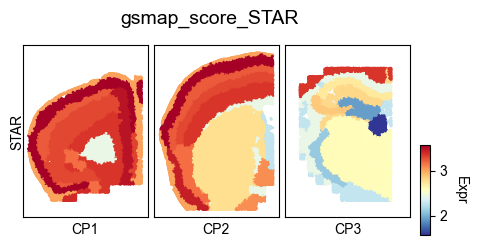

In [44]:
# current_module = 'Grin2a_basal'
# current_module = 'IEG_score_RIBO'
current_module = 'gsmap_score_STAR'
current_palette = 'RdYlBu_r'

fig, axs = plt.subplots(figsize=(5, 3), nrows=1, ncols=3, 
                        subplot_kw={'aspect': 'equal'},
                        sharex=True, sharey=True)

# Calculate value ranges for star and ribo to set appropriate hue norms
ribo_values = []

for df in [pfc_coords, st_coords, hp_coords]:
    ribo_values.extend(df[f'{current_module}'].dropna().values)

# star_min, star_max = np.min(star_values), np.max(star_values)
ribo_min, ribo_max = np.min(ribo_values), np.max(ribo_values)

# Create symmetric ranges around zero for better visualization
# star_abs_max = max(abs(star_min), abs(star_max))
ribo_abs_max = max(abs(ribo_min), abs(ribo_max))

# star_norm = (-star_abs_max, star_abs_max)
# ribo_norm = (0, ribo_abs_max) # Grin2a_basal
ribo_norm = (ribo_min, ribo_max) # IEG_score_RIBO

# star_norm = (-0.2, 0.2)
# ribo_norm = (-0.2, 0.2)
# print(star_norm)
print(ribo_norm)

sns.scatterplot(data=pfc_coords[pfc_coords[f'{current_module}'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[0], rasterized=True)
sns.scatterplot(data=st_coords[st_coords[f'{current_module}'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[1], rasterized=True)
sns.scatterplot(data=hp_coords[hp_coords[f'{current_module}'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[2], rasterized=True)


# sns.scatterplot(data=pfc_coords, x='global_x', y='global_y', hue=f'{current_module}_STAR', palette='bwr', hue_norm=star_norm, s=3, edgecolor=None, ax=axs[0, 0], rasterized=True)
# sns.scatterplot(data=st_coords, x='global_x', y='global_y', hue=f'{current_module}_STAR', palette='bwr', hue_norm=star_norm, s=3, edgecolor=None, ax=axs[0, 1], rasterized=True)
# sns.scatterplot(data=hp_coords, x='global_x', y='global_y', hue=f'{current_module}_STAR', palette='bwr', hue_norm=star_norm, s=3, edgecolor=None, ax=axs[0, 2], rasterized=True)


sns.scatterplot(data=pfc_coords, x='global_x', y='global_y', hue=f'{current_module}', palette=current_palette, hue_norm=ribo_norm, s=3, edgecolor=None, ax=axs[0], rasterized=True)
sns.scatterplot(data=st_coords, x='global_x', y='global_y', hue=f'{current_module}', palette=current_palette, hue_norm=ribo_norm, s=3, edgecolor=None, ax=axs[1], rasterized=True)
sns.scatterplot(data=hp_coords, x='global_x', y='global_y', hue=f'{current_module}', palette=current_palette, hue_norm=ribo_norm, s=3, edgecolor=None, ax=axs[2], rasterized=True)


for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.get_legend().remove()

# Add y-axis labels
axs[0].set_ylabel('STAR', rotation=90, va='center')
# axs[1, 0].set_ylabel('RIBO', rotation=90, va='center')

# Add x-axis labels
axs[0].set_xlabel('CP1', ha='center')
axs[1].set_xlabel('CP2', ha='center')
axs[2].set_xlabel('CP3', ha='center')

# cax = fig.add_axes([0.92, 0.55, 0.02, 0.3])
# norm = plt.Normalize(star_norm[0], star_norm[1])
# sm = plt.cm.ScalarMappable(cmap="bwr", norm=norm)  # create mappable for colorbar
# cbar1 = fig.colorbar(sm, cax=cax)
# cbar1.set_label('ΔExpr', rotation=270, labelpad=15)

cax = fig.add_axes([0.92, 0.15, 0.02, 0.3])
norm = plt.Normalize(ribo_norm[0], ribo_norm[1])
sm = plt.cm.ScalarMappable(cmap=current_palette, norm=norm)  # create mappable for colorbar
cbar2 = fig.colorbar(sm, cax=cax)
cbar2.set_label('Expr', rotation=270, labelpad=15)

fig.suptitle(f'{current_module}', fontsize=14, y=0.9)
plt.subplots_adjust(wspace=0.05, hspace=0.05) 
plt.savefig(os.path.join(fig_path, f'spatial_scatter_gsmap_STAR.pdf'), bbox_inches='tight', dpi=300)
# plt.savefig(os.path.join(fig_path, f'spatial_scatter_IEG_score_diff_RIBO.pdf'), bbox_inches='tight', dpi=300)
plt.show()

In [50]:
use_custom_norm = False
custom_norm = (-0.05, 0.05)

use_consistent_norm = True

# for current_module in coor_df.index:
# for current_module in ['SNAP-n']:
for current_module in ['OXFOS_score', 'Ribosome_score', 'Response_to_dopamine_score', 'Sig_dopamine_score', 'Sig_serotonin_score', 'IEG_score', 'ARG_score']:
# for current_module in deg_list:
# for current_module in top_genes_dict.keys():

    # current_module = 'Arc'
    current_palette = 'RdBu_r'
    fig, axs = plt.subplots(figsize=(5, 5), nrows=2, ncols=3, 
                            subplot_kw={'aspect': 'equal'},
                            sharex=True, sharey=True)

    # Calculate value ranges for star and ribo to set appropriate hue norms
    star_values = []
    ribo_values = []
    star_norm = None
    ribo_norm = None

    for df in [pfc_coords, st_coords, hp_coords]:
        star_values.extend(df[f'{current_module}_STAR'].dropna().values)
        ribo_values.extend(df[f'{current_module}_RIBO'].dropna().values)

    if star_values != []:
        star_min, star_max = np.min(star_values), np.max(star_values)
        star_abs_max = max(abs(star_min), abs(star_max))
        star_norm = (-star_abs_max, star_abs_max)
        if use_custom_norm:
            star_norm = custom_norm
        
    
    if ribo_values != []:
        ribo_min, ribo_max = np.min(ribo_values), np.max(ribo_values)
        ribo_abs_max = max(abs(ribo_min), abs(ribo_max))
        ribo_norm = (-ribo_abs_max, ribo_abs_max)
        if use_custom_norm:
            ribo_norm = custom_norm

    print(star_norm)
    print(ribo_norm)

    if use_consistent_norm:
        norm_min = min(star_norm[0], ribo_norm[0])
        norm_max = max(star_norm[1], ribo_norm[1])
        star_norm = (norm_min, norm_max)
        ribo_norm = (norm_min, norm_max)

    sns.scatterplot(data=pfc_coords[pfc_coords[f'{current_module}_STAR'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[0, 0], rasterized=True)
    sns.scatterplot(data=st_coords[st_coords[f'{current_module}_STAR'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[0, 1], rasterized=True)
    sns.scatterplot(data=hp_coords[hp_coords[f'{current_module}_STAR'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[0, 2], rasterized=True)
    sns.scatterplot(data=pfc_coords[pfc_coords[f'{current_module}_RIBO'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[1, 0], rasterized=True)
    sns.scatterplot(data=st_coords[st_coords[f'{current_module}_RIBO'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[1, 1], rasterized=True)
    sns.scatterplot(data=hp_coords[hp_coords[f'{current_module}_RIBO'].isna()], x='global_x', y='global_y', color='#ebebeb', s=3, edgecolor=None, ax=axs[1, 2], rasterized=True)
    
    sns.scatterplot(data=pfc_coords, x='global_x', y='global_y', hue=f'{current_module}_STAR', palette=current_palette, hue_norm=star_norm, s=3, edgecolor=None, ax=axs[0, 0], rasterized=True)
    sns.scatterplot(data=st_coords, x='global_x', y='global_y', hue=f'{current_module}_STAR', palette=current_palette, hue_norm=star_norm, s=3, edgecolor=None, ax=axs[0, 1], rasterized=True)
    sns.scatterplot(data=hp_coords, x='global_x', y='global_y', hue=f'{current_module}_STAR', palette=current_palette, hue_norm=star_norm, s=3, edgecolor=None, ax=axs[0, 2], rasterized=True)

    sns.scatterplot(data=pfc_coords, x='global_x', y='global_y', hue=f'{current_module}_RIBO', palette=current_palette, hue_norm=ribo_norm, s=3, edgecolor=None, ax=axs[1, 0], rasterized=True)
    sns.scatterplot(data=st_coords, x='global_x', y='global_y', hue=f'{current_module}_RIBO', palette=current_palette, hue_norm=ribo_norm, s=3, edgecolor=None, ax=axs[1, 1], rasterized=True)
    sns.scatterplot(data=hp_coords, x='global_x', y='global_y', hue=f'{current_module}_RIBO', palette=current_palette, hue_norm=ribo_norm, s=3, edgecolor=None, ax=axs[1, 2], rasterized=True)


    for ax in axs.flat:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        try:
            ax.get_legend().remove()
        except:
            pass

    # Add y-axis labels
    axs[0, 0].set_ylabel('STAR', rotation=90, va='center')
    axs[1, 0].set_ylabel('RIBO', rotation=90, va='center')

    # Add x-axis labels
    axs[1, 0].set_xlabel('CP1', ha='center')
    axs[1, 1].set_xlabel('CP2', ha='center')
    axs[1, 2].set_xlabel('CP3', ha='center')

    if star_norm is not None:
        cax = fig.add_axes([0.92, 0.55, 0.02, 0.3])
        norm = plt.Normalize(star_norm[0], star_norm[1])
        sm = plt.cm.ScalarMappable(cmap=current_palette, norm=norm)  # create mappable for colorbar
        cbar1 = fig.colorbar(sm, cax=cax)
        cbar1.set_label('ΔExpr', rotation=270, labelpad=15)

    if ribo_norm is not None:
        cax = fig.add_axes([0.92, 0.15, 0.02, 0.3])
        norm = plt.Normalize(ribo_norm[0], ribo_norm[1])
        sm = plt.cm.ScalarMappable(cmap=current_palette, norm=norm)  # create mappable for colorbar
        cbar2 = fig.colorbar(sm, cax=cax)
        cbar2.set_label('ΔExpr', rotation=270, labelpad=15)

    fig.suptitle(f'{current_module}', fontsize=14, y=0.9)
    plt.subplots_adjust(wspace=0.05, hspace=0.05) 
    plt.savefig(os.path.join(fig_path, f'spatial_scatter_{current_module}_Neuron_sig_consistent.pdf'), bbox_inches='tight', dpi=300)
    plt.close()
    # plt.show()

(-0.053160331314155734, 0.053160331314155734)
(-0.029897069012252885, 0.029897069012252885)
(-0.08067528146412678, 0.08067528146412678)
(-0.03999987806845587, 0.03999987806845587)
(-0.012653236801636058, 0.012653236801636058)
(-0.020324687358053872, 0.020324687358053872)
(-0.027133388199011108, 0.027133388199011108)
(-0.04427764669867426, 0.04427764669867426)
(-0.04028264774598233, 0.04028264774598233)
(-0.027689059939236225, 0.027689059939236225)
(-0.047600889860679715, 0.047600889860679715)
(-0.062536548352554, 0.062536548352554)
(-0.01856803302494848, 0.01856803302494848)
(-0.0165668518197238, 0.0165668518197238)
